# 1. Introdução
Este projeto visa analisar a evolução das temperaturas médias globais por país ao longo dos anos, utilizando dados da FAO (Food and Agriculture Organization). Serão exploradas variações por país, tendências históricas, tratamento de dados ausentes e outliers, além da criação de novas features para alimentar modelos de machine learning.


# 2. Coleta e descrição dos dados

### 2.1 Temperatura

Dataset de temperatura carregado com sucesso!

--- Dataset após melt e renomeação de colunas ---
   Area Code      Country  Months Code    Months  Element Code  \
0          2  Afghanistan         7001   January          7271   
1          2  Afghanistan         7001   January          6078   
2          2  Afghanistan         7002  February          7271   
3          2  Afghanistan         7002  February          6078   
4          2  Afghanistan         7003     March          7271   

              Element Unit  Year  Temperature_Change  
0  Temperature change   °C  1961               0.777  
1  Standard Deviation   °C  1961               1.950  
2  Temperature change   °C  1961              -1.743  
3  Standard Deviation   °C  1961               2.597  
4  Temperature change   °C  1961               0.516  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569704 entries, 0 to 569703
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------     

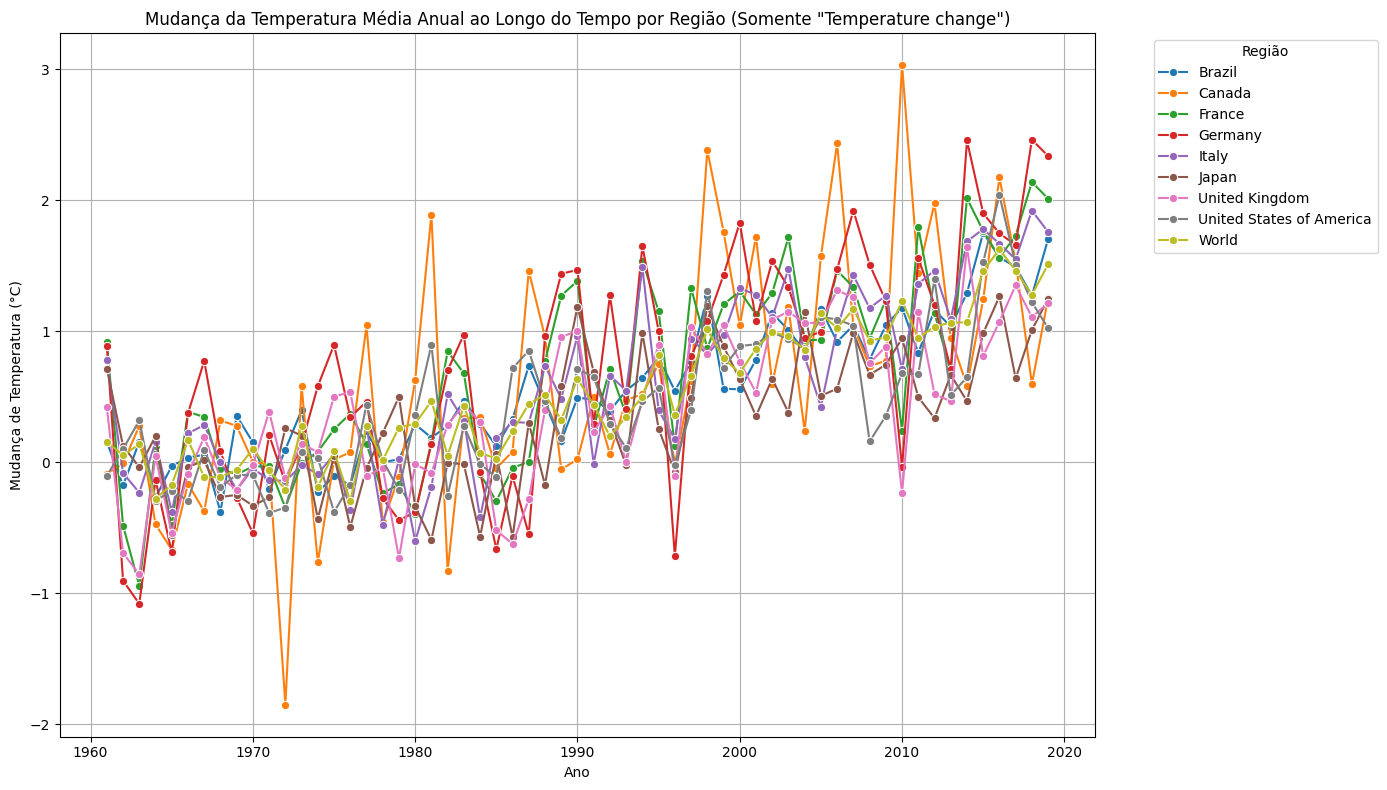

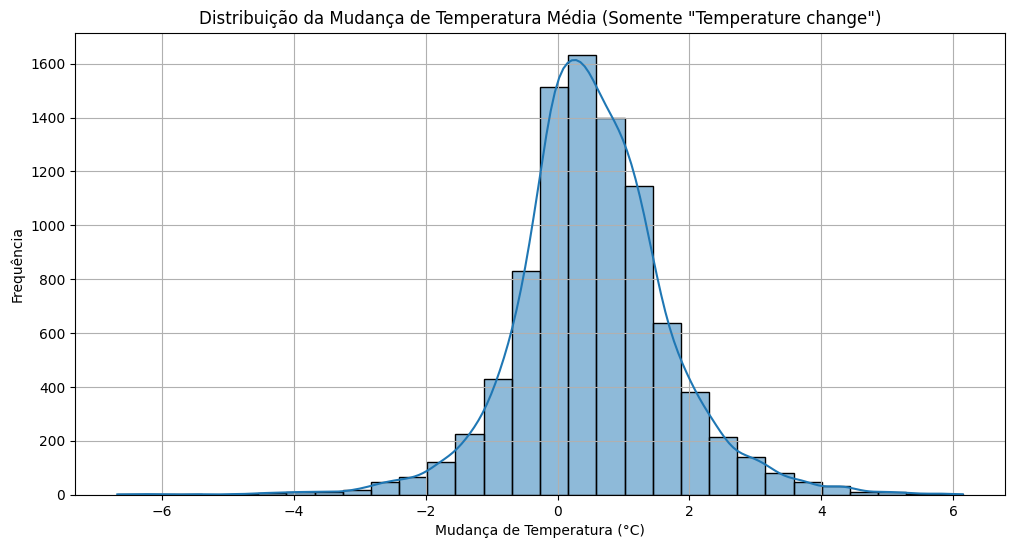

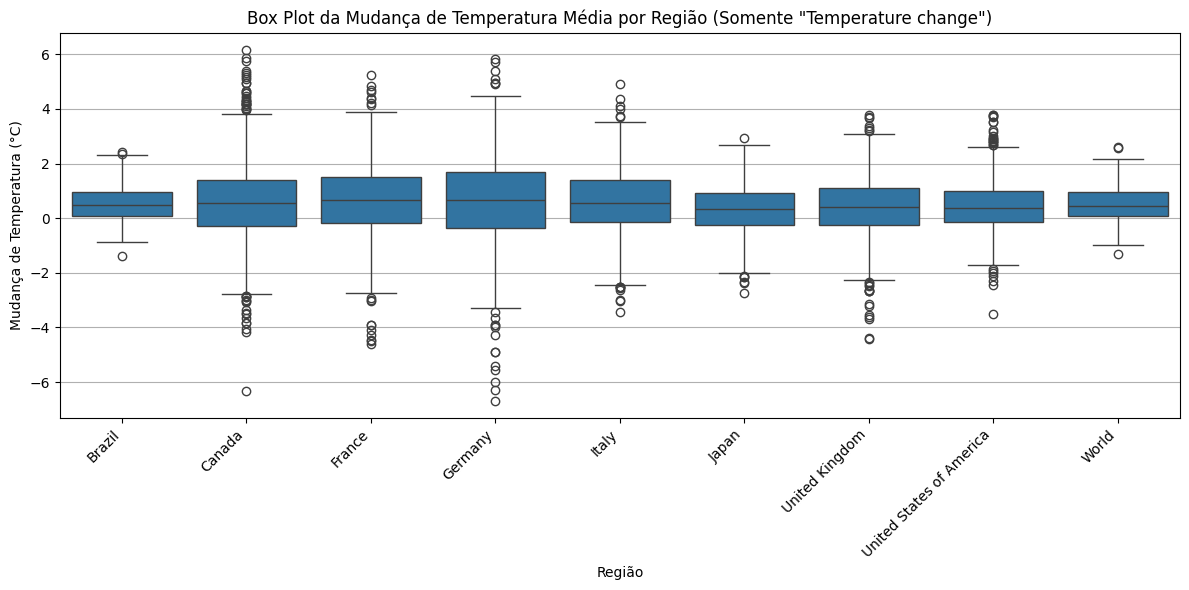


--- Verificando valores ausentes no dataset de temperatura final ---
Area Code             0
Country               0
Months Code           0
Months                0
Element Code          0
Element               0
Unit                  0
Year                  0
Temperature_Change    0
dtype: int64

--- Percentual de valores ausentes ---
Area Code             0.0
Country               0.0
Months Code           0.0
Months                0.0
Element Code          0.0
Element               0.0
Unit                  0.0
Year                  0.0
Temperature_Change    0.0
dtype: float64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carregamento e Visão Geral Inicial ---
try:
    df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
    print("Dataset de temperatura carregado com sucesso!")
except FileNotFoundError:
    print("Erro: O arquivo 'Environment_Temperature_change_E_All_Data_NOFLAG.csv' não foi encontrado.")
    exit()

# --- Ajuste para o Formato do Dataset (Melting) ---
year_columns = [col for col in df.columns if col.startswith('Y') and len(col) == 5]
id_vars = [col for col in df.columns if col not in year_columns and 'F' not in col and 'Flag' not in col]

df_melted = df.melt(id_vars=id_vars,
                     value_vars=year_columns,
                     var_name='Year',
                     value_name='Temperature_Change')

df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)
df_melted.rename(columns={'Area': 'Country'}, inplace=True)

print("\n--- Dataset após melt e renomeação de colunas ---")
print(df_melted.head())
print(df_melted.info())
print("\n--- Valores únicos na coluna 'Element' ---")
print(df_melted['Element'].unique())


# --- 2. Filtragem de Dados de Interesse e do 'Element' ---

# Filtrar para incluir apenas 'Temperature change' na coluna 'Element'
# Esta é a correção principal para esta etapa!
df_filtered_temp = df_melted[df_melted['Element'] == 'Temperature change'].copy()

# Países do G7 e outras regiões de interesse
g7_countries = ['Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom', 'United States of America']
selected_regions = ['Brazil'] + g7_countries + ['World']

# Filtrar o DataFrame para incluir apenas as regiões de interesse
df_filtered_temp = df_filtered_temp[df_filtered_temp['Country'].isin(selected_regions)].copy()

print(f"\n--- Dataset de temperatura filtrado para as regiões de interesse e 'Temperature change' ({len(df_filtered_temp['Country'].unique())} regiões) ---")
print(df_filtered_temp['Country'].unique())
print(df_filtered_temp.head())
print(df_filtered_temp.info())

# --- 3. Análise Exploratória Detalhada com Visualizações (Parte 1: Tendências Temporais) ---
# Execução dos gráficos novamente para ver o efeito da filtragem do 'Element'

print("\n--- Gerando visualizações de tendências temporais (AGORA COM 'Temperature change' APENAS) ---")

temperature_column = 'Temperature_Change'
df_filtered_temp.dropna(subset=[temperature_column, 'Year'], inplace=True)

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_filtered_temp, x='Year', y=temperature_column, hue='Country', marker='o', errorbar=None)
plt.title(f'Mudança da Temperatura Média Anual ao Longo do Tempo por Região (Somente "Temperature change")')
plt.xlabel('Ano')
plt.ylabel(f'Mudança de Temperatura (°C)')
plt.grid(True)
plt.legend(title='Região', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(df_filtered_temp[temperature_column], kde=True, bins=30)
plt.title(f'Distribuição da Mudança de Temperatura Média (Somente "Temperature change")')
plt.xlabel(f'Mudança de Temperatura (°C)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y=temperature_column, data=df_filtered_temp)
plt.title(f'Box Plot da Mudança de Temperatura Média por Região (Somente "Temperature change")')
plt.xlabel('Região')
plt.ylabel(f'Mudança de Temperatura (°C)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- Pré-processamento Adicional: Valores Ausentes e Outliers ---
print("\n--- Verificando valores ausentes no dataset de temperatura final ---")
print(df_filtered_temp.isnull().sum())
print("\n--- Percentual de valores ausentes ---")
print(df_filtered_temp.isnull().sum() / len(df_filtered_temp) * 100)


### 2.2 População